# Exploration of COLET dataset

The original dataset from this [paper](https://doi.org/10.1016/j.cmpb.2022.106989) has a single *.mat* file containing tabular data from the experiments.

Since this format is not easy to use with *Python*, a MATLAB script was used to extract the relevant data as *.csv* files, which can be easily loaded with *Pandas* library.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

COLET_DATASET_DIR = Path("../datasets/COLET_CSV")
EXP_SELECT = "participant_02/Task_4"

In [40]:
# Load the different daat from eye tracker
gaze_df = pd.read_csv(COLET_DATASET_DIR / EXP_SELECT / "gaze.csv")
pupil_df = pd.read_csv(COLET_DATASET_DIR / EXP_SELECT / "pupil.csv")
blink_df = pd.read_csv(COLET_DATASET_DIR / EXP_SELECT / "blinks.csv")

print(f"Loaded {gaze_df.shape[0]} gaze records:")
display(gaze_df.head(1))
print(f"Loaded {pupil_df.shape[0]} pupil records:")
display(pupil_df.head(5))
print(f"Loaded {blink_df.shape[0]} blink records:")
display(blink_df.head())

Loaded 11957 gaze records:


,gaze_timestamp,confidence,norm_pos_x,norm_pos_y,gaze_point_3d_x,gaze_point_3d_y,gaze_point_3d_z
0,90995.126606,0.999002,0.411914,0.653381,-23.657088,-33.094082,173.318342


Loaded 23918 pupil records:


,pupil_timestamp,eye_id,confidence_px,diameter_px,diameter_mm,confidence_mm
0,90995.124672,0,0.998665,32.854129,3.683050,0.808000
1,90995.124672,0,1.000000,32.852310,NaN,NaN
2,90995.128540,1,0.999340,33.819032,3.774079,0.904153
3,90995.128540,1,1.000000,33.857292,NaN,NaN
4,90995.132412,0,0.998830,32.636205,3.661462,0.807920


Loaded 10 blink records:


,id,start_timestamp,duration,end_timestamp,start_frame_index,index,end_frame_index,confidence,filter_response,base_data
0,1,90997.116431,0.208093,90997.324524,59,62,65,0.589238,0.5088037159434569 0.5532481603879015 0.597692...,90997.116431 90997.121122 90997.124455 90997.1...
1,2,90997.652829,0.279633,90997.932462,75,79,83,0.634712,0.5391463337742395 0.5835907782186839 0.628035...,90997.652829 90997.656448 90997.660702 90997.6...
2,3,91002.054042,0.214465,91002.268507,206,209,213,0.606721,0.5076595276903548 0.5521039721347994 0.596548...,91002.054042 91002.056646 91002.060434 91002.0...
3,1,91008.652510,0.196229,91008.848739,4,7,10,0.550264,0.5437622274763881 0.5882066719208326 0.632651...,91008.65251 91008.65665 91008.660649 91008.664...
4,2,91010.344604,3.856091,91014.200695,55,112,170,0.130683,0.5352775153985769 0.49083307095413253 0.54960...,91010.344604 91010.34881 91010.35763500001 910...


In [41]:
# Some insights about the duration of the gaze and pupil data
gaze_start_time = gaze_df['gaze_timestamp'].min()
gaze_end_time = gaze_df['gaze_timestamp'].max()
pupil_start_time = pupil_df['pupil_timestamp'].min()
pupil_end_time = pupil_df['pupil_timestamp'].max()
print(f"Gaze data duration: {gaze_end_time - gaze_start_time} s")
print(f"Pupil data duration: {pupil_end_time - pupil_start_time} s")

print(f"Estimated gaze frequency: {gaze_df.shape[0] / (gaze_end_time - gaze_start_time):.2f} Hz")
print(f"Estimated pupil (right) frequency: {pupil_df[pupil_df.eye_id == 1].shape[0] / (pupil_end_time - pupil_start_time):.2f} Hz")
print(f"Estimated pupil (left) frequency: {pupil_df[pupil_df.eye_id == 0].shape[0] / (pupil_end_time - pupil_start_time):.2f} Hz")


Gaze data duration: 49.019973499991465 s
Pupil data duration: 49.023875999992015 s
Estimated gaze frequency: 243.92 Hz
Estimated pupil (right) frequency: 243.92 Hz
Estimated pupil (left) frequency: 243.96 Hz


It looks like they are using two methods to calculate the pupil related metrics ('2D c++' / '3D c++'). It also seems that there is always one that has a higher confidence, so the diameter will be chosen from the highest confidence value.

Also, it seems like it is always switching between left and right eye for a **combined** frequency of 240Hz

In [48]:
display((pupil_df[~pupil_df['diameter_mm'].isna()]['confidence_mm'] > 0.95).sum())
display((pupil_df[pupil_df['diameter_mm'].isna()]['confidence_px'] > 0.95).sum())

np.int64(508)

np.int64(10412)

In [64]:
# Sort pupil data by choosing best confidence for each timestamp for each eye
pupil_df_left = pupil_df[(pupil_df['eye_id'] == 0) & pupil_df['diameter_mm'].isna()]
pupil_df_right = pupil_df[(pupil_df['eye_id'] == 1) & pupil_df['diameter_mm'].isna()]
pupil_df_best = pd.merge_asof(pupil_df_left.sort_values('pupil_timestamp'), pupil_df_right.sort_values('pupil_timestamp'), on='pupil_timestamp', direction='nearest', tolerance=1.0/240*2, suffixes=('_left', '_right'))
pupil_df.reset_index(drop=True, inplace=True)
pupil_df_best.drop(columns=[c for c in pupil_df_best.columns if c.startswith('confidence_mm') or c.startswith('diameter_mm') or c.startswith('eye_id_')], inplace=True)
# Change confidence to 0 for values out of range
pupil_df_best.loc[pupil_df_best['diameter_px_left'] < 15, 'confidence_px_left'] = 0
pupil_df_best.loc[pupil_df_best['diameter_px_left'] > 100, 'confidence_px_left'] = 0
pupil_df_best.loc[pupil_df_best['diameter_px_right'] < 15, 'confidence_px_right'] = 0
pupil_df_best.loc[pupil_df_best['diameter_px_right'] > 100, 'confidence_px_right'] = 0
print(f"Length of pupil_df_best: {pupil_df_best.shape[0]}")


Length of pupil_df_best: 5980


In [65]:
# Merge gaze and pupil data on closest timestamp match
fs = 120

merged_df = pd.merge_asof(pupil_df_best.sort_values('pupil_timestamp'),
                        gaze_df.sort_values('gaze_timestamp'),
                          left_on='pupil_timestamp',
                          right_on='gaze_timestamp',
                          direction='nearest',
                          tolerance=1.0/fs*2)  # tolerance in ms
print(f"There are {merged_df[merged_df.confidence.isna()].index.size} non matching timestamp within the limits")
# Since only one value, drop the row
merged_df_clean = merged_df.dropna()
# Let's reindex the dataframe using timestamp starting from 0 and dropping the original timestamp columns
merged_df_clean['timestamp'] = merged_df_clean['pupil_timestamp'] - pupil_start_time
merged_df_clean.drop(columns=['gaze_timestamp', 'pupil_timestamp'], inplace=True)
# Let's combine timestamps too close to each other (less than 2 of the sampling rate) by averaging their values
# display(merged_df_clean.groupby((merged_df_clean['timestamp'] // (1.0/240/2)).astype(int)).count().sort_values(by='confidence', ascending=False).head(10))
merged_df_clean = merged_df_clean.groupby((merged_df_clean['timestamp'] // (1.0/fs/2)).astype(int)).mean().reset_index(drop=True)
print(f"Final merged dataset has {merged_df_clean.shape[0]} records at {fs} Hz")

merged_df_clean.head()

There are 0 non matching timestamp within the limits
Final merged dataset has 5979 records at 120 Hz


,confidence_px_left,diameter_px_left,confidence_px_right,diameter_px_right,confidence,norm_pos_x,norm_pos_y,gaze_point_3d_x,gaze_point_3d_y,gaze_point_3d_z,timestamp
0,1.0,32.852310,1.0,33.857292,0.999002,0.411914,0.653381,-23.657088,-33.094082,173.318342,0.000000
1,1.0,32.632725,1.0,33.857292,0.999085,0.410307,0.652812,-23.829218,-32.608353,171.206656,0.007740
2,1.0,32.858391,1.0,33.876308,0.999013,0.408774,0.653903,-23.996110,-32.421654,169.237849,0.015789
3,1.0,33.127026,1.0,34.077438,0.998943,0.409687,0.654298,-23.939893,-32.756741,170.682029,0.024170
4,1.0,32.430450,1.0,34.077438,0.998801,0.409026,0.653587,-24.009548,-32.485490,169.850272,0.032197


Last thing is to downsample to 60 Hz since it will be the max freq. of the Tobii Pro fusion I'm using

In [66]:
# Downsample merged data to 60 Hz
# Convert timestamp to datetime for resampling
merged_df_clean_resampled = merged_df_clean.copy()
merged_df_clean_resampled['timestamp'] = pd.to_timedelta(merged_df_clean_resampled['timestamp'], unit='s')
merged_df_clean_resampled.set_index('timestamp', inplace=True)
merged_df_clean_resampled = merged_df_clean_resampled.resample('16.67ms').nearest().interpolate()  # Resample to 60 Hz and interpolate missing values
merged_df_clean_resampled.reset_index(inplace=True)
merged_df_clean_resampled['timestamp'] = merged_df_clean_resampled['timestamp'].dt.total_seconds()  # Convert back to seconds
print(f"Final merged and resampled dataset has {merged_df_clean_resampled.shape[0]} records at 60 Hz")

Final merged and resampled dataset has 2941 records at 60 Hz


## Pupil analysis

Let's start by plotting the left and right eye data

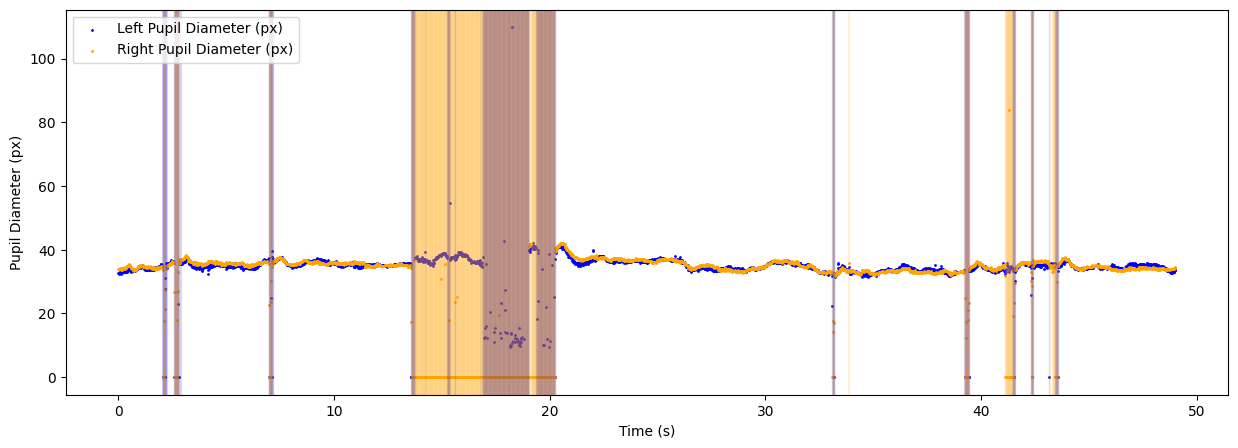

In [79]:
pupil_clean_data = merged_df_clean_resampled[['timestamp', 'diameter_px_left', 'confidence_px_left', 'diameter_px_right', 'confidence_px_right']]
fig, ax = plt.subplots(figsize=(15, 5))
pupil_clean_data.plot(x='timestamp', y='diameter_px_left', kind='scatter', sizes=[1], label='Left Pupil Diameter (px)', color='blue', ax=ax)
pupil_clean_data.plot(x='timestamp', y='diameter_px_right', kind='scatter', sizes=[1], label='Right Pupil Diameter (px)', color='orange', ax=ax)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Pupil Diameter (px)')

# Add low confidence zones
low_confidence_left = pupil_clean_data[pupil_clean_data['confidence_px_left'] <= 0.95]
for _, row in low_confidence_left.iterrows():
    ax.axvspan(row['timestamp'] - 1/120, row['timestamp'] + 1/120, color='blue', alpha=0.1)
low_confidence_right = pupil_clean_data[pupil_clean_data['confidence_px_right'] <= 0.95]
for _, row in low_confidence_right.iterrows():
    ax.axvspan(row['timestamp'] - 1/120, row['timestamp'] + 1/120, color='orange', alpha=0.1)

Maybe it is best to keep the one that as the most confidence for a given window (for now it's gonna be the whole task)

Number of good samples (confidence > 0.95) for left pupil: 2658 out of 2941 (90.38%)
Number of good samples (confidence > 0.95) for right pupil: 2453 out of 2941 (83.41%)


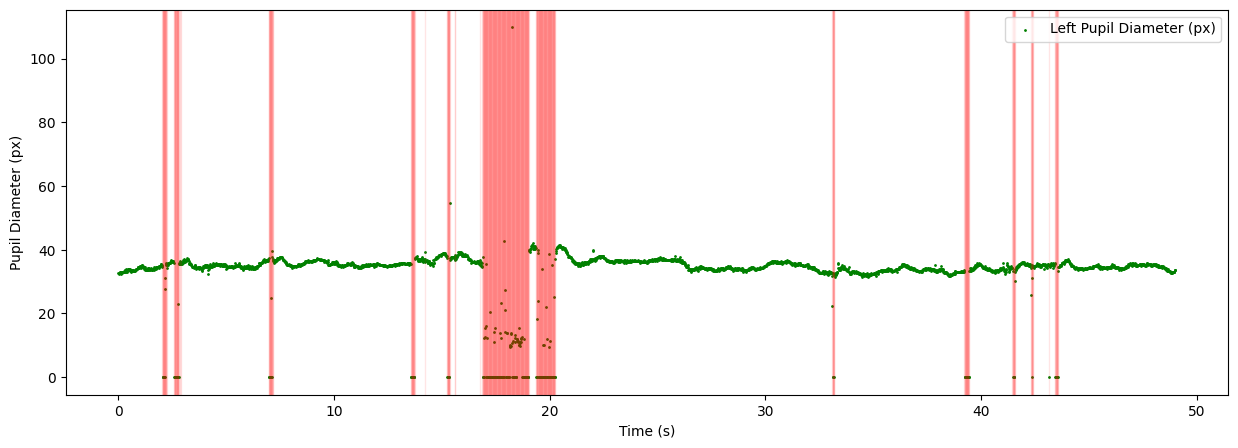

In [80]:
num_good_samples_left = (pupil_clean_data['confidence_px_left'] > 0.95).sum()
num_good_samples_right = (pupil_clean_data['confidence_px_right'] > 0.95).sum()
print(f"Number of good samples (confidence > 0.95) for left pupil: {num_good_samples_left} out of {pupil_clean_data.shape[0]} ({num_good_samples_left / pupil_clean_data.shape[0] * 100:.2f}%)")
print(f"Number of good samples (confidence > 0.95) for right pupil: {num_good_samples_right} out of {pupil_clean_data.shape[0]} ({num_good_samples_right / pupil_clean_data.shape[0] * 100:.2f}%)")

# Keep the best eye
best_eye = 'left' if num_good_samples_left > num_good_samples_right else 'right'
pupil_clean_data_best = pupil_clean_data.copy()
pupil_clean_data_best['diameter_px'] = pupil_clean_data_best[f'diameter_px_{best_eye}']
pupil_clean_data_best['confidence_px'] = pupil_clean_data_best[f'confidence_px_{best_eye}']
pupil_clean_data_best.drop(columns=['diameter_px_left', 'confidence_px_left', 'diameter_px_right', 'confidence_px_right'], inplace=True)

fig, ax = plt.subplots(figsize=(15, 5))
pupil_clean_data_best.plot(x='timestamp', y='diameter_px', kind='scatter', sizes=[1], label=f'{best_eye.capitalize()} Pupil Diameter (px)', color='green', ax=ax)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Pupil Diameter (px)')
# Add low confidence zones
low_confidence = pupil_clean_data_best[pupil_clean_data_best['confidence_px'] <= 0.95]
for _, row in low_confidence.iterrows():
    ax.axvspan(row['timestamp'] - 1/120, row['timestamp'] + 1/120, color='red', alpha=0.1)

In [ ]:
# Keep only the worse confidence level between gaze and pupil
# Removing low confidence samples
pupil_clean_data_final = pupil_clean_data_best[pupil_clean_data_best['confidence_px'] > 0.95]

2. Dilation speed outliers filtering [(this paper)](https://doi.org/10.3758/s13428-018-1075-y)

Dilation speed threshold: 100.90


Text(0, 0.5, 'Pupil Diameter (px)')

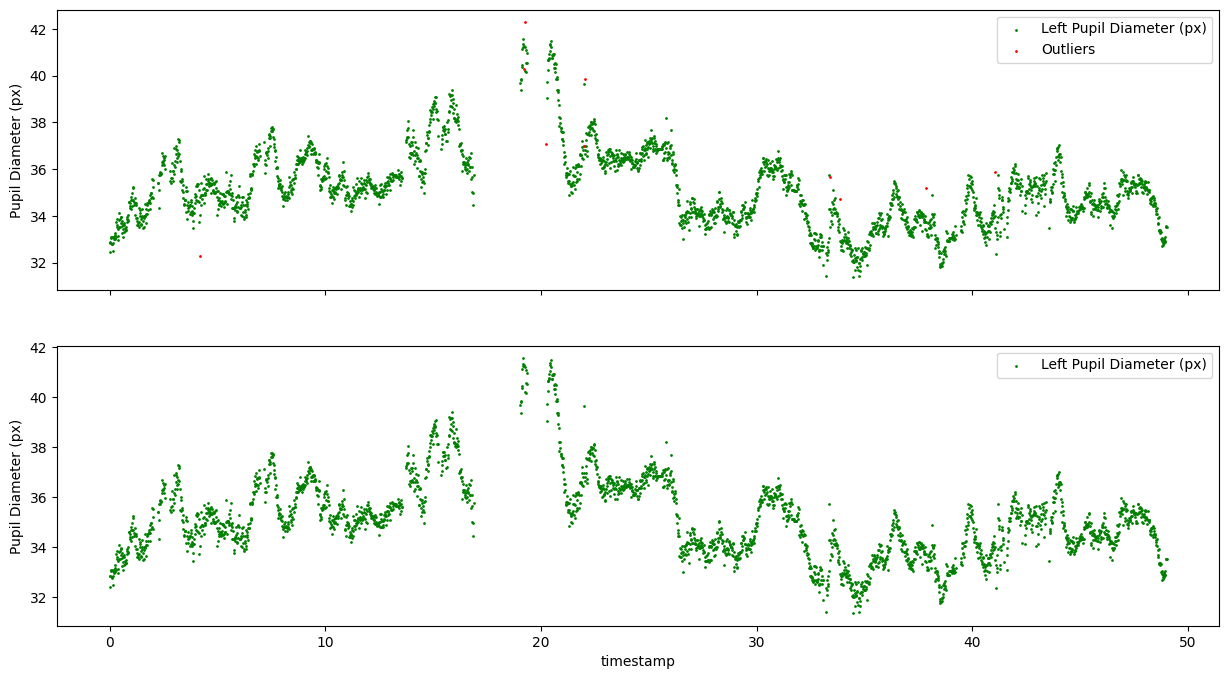

In [99]:
DILATION_FACTOR = 10.0 # n times the MAD

def dilation_speed(data, time_col='timestamp', diameter_col='diameter_px'):
    speed_before = (data[diameter_col] - data[diameter_col]).shift(1) / (data[time_col] - data[time_col].shift(1))
    speed_after = (data[diameter_col].shift(-1) - data[diameter_col]) / (data[time_col].shift(-1) - data[time_col])
    return pd.concat([speed_before.abs(), speed_after.abs()], axis=1).max(axis=1)

pupil_clean_data_final['dilation_speed'] = dilation_speed(pupil_clean_data_final)
# Find the threshold
mad = (pupil_clean_data_final['dilation_speed'] - pupil_clean_data_final['dilation_speed'].median()).abs().median()
threshold = pupil_clean_data_final['dilation_speed'].median() + DILATION_FACTOR * mad

print(f"Dilation speed threshold: {threshold:.2f}")

# Marked as outliers the points where dilation speed is above the threshold
pupil_clean_data_final['is_outlier'] = pupil_clean_data_final['dilation_speed'] > threshold

fig, axs = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
pupil_clean_data_final[~pupil_clean_data_final['is_outlier']].plot(x='timestamp', y='diameter_px', kind='scatter', sizes=[1], label=f'{best_eye.capitalize()} Pupil Diameter (px)', color='green', ax=axs[0])
pupil_clean_data_final[pupil_clean_data_final['is_outlier']].plot(x='timestamp', y='diameter_px', kind='scatter', sizes=[1], label='Outliers', color='red', ax=axs[0])
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Pupil Diameter (px)')
axs[0].legend()

pupil_clean_data_final[~pupil_clean_data_final['is_outlier']].plot(x='timestamp', y='diameter_px', kind='scatter', sizes=[1], label=f'{best_eye.capitalize()} Pupil Diameter (px)', color='green', ax=axs[1])
axs[1].set_ylabel('Pupil Diameter (px)')

2. Identify gaps

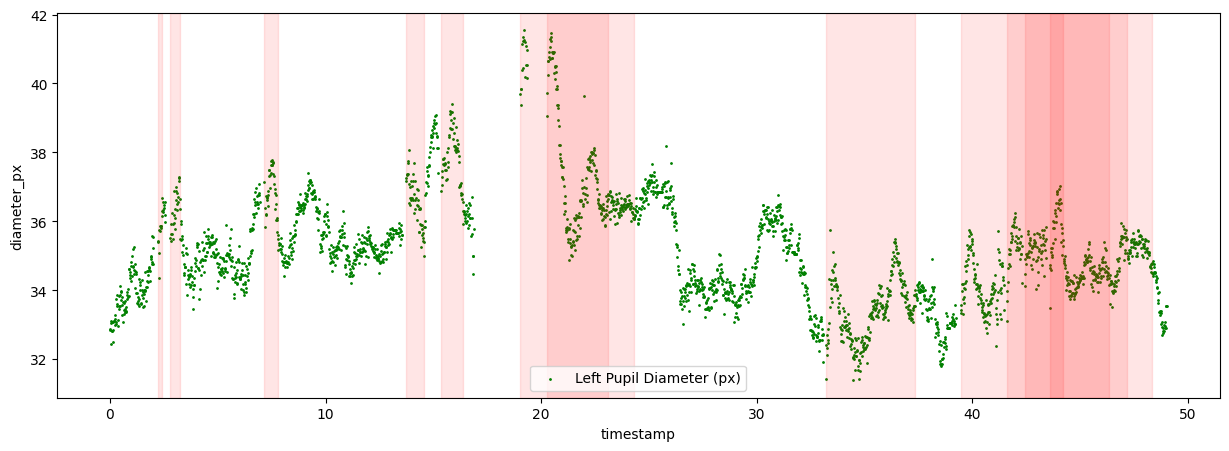

In [104]:
GAPS_THRESHOLD = 75 # milliseconds
pupil_clean_data_final['gap'] = pupil_clean_data_final['timestamp'].diff() > (GAPS_THRESHOLD / 1000)

# Display the gaps
fig, ax = plt.subplots(figsize=(15, 5))
pupil_clean_data_final[~pupil_clean_data_final['is_outlier']].plot(x='timestamp', y='diameter_px', kind='scatter', sizes=[1], label=f'{best_eye.capitalize()} Pupil Diameter (px)', color='green', ax=ax)
for idx, row in pupil_clean_data_final[pupil_clean_data_final['gap']].iterrows():
    ax.axvspan( row['timestamp'], pupil_clean_data_final.iloc[idx+1]['timestamp'], color='red', alpha=0.1)
    

## Gaze analysis

Let's now visualize the gaze data we are working with

(0.0, 1.0)

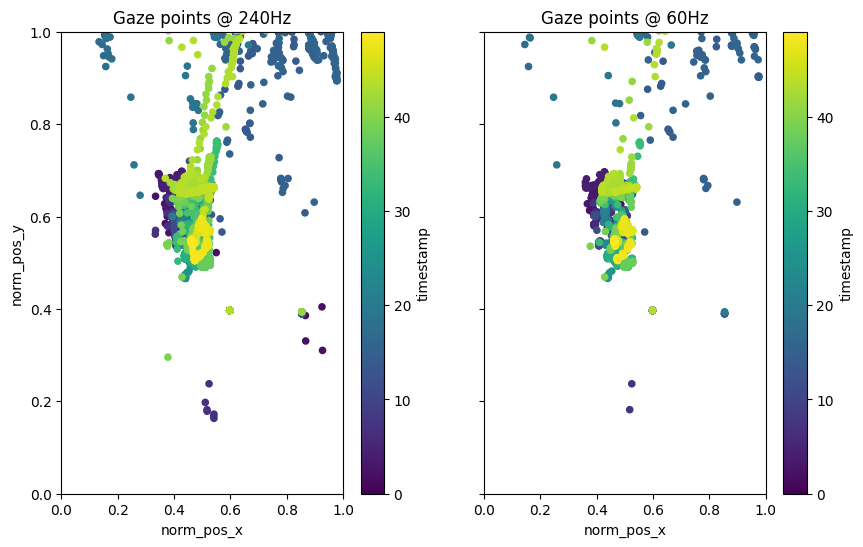

In [135]:
from matplotlib import colormaps

fig, axs = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
colormap = colormaps.get_cmap("viridis")
merged_df_clean.plot("norm_pos_x", "norm_pos_y", kind='scatter', c='timestamp', colormap=colormap, title="Gaze points @ 240Hz", ax=axs[0])
merged_df_clean_resampled.plot("norm_pos_x", "norm_pos_y", kind='scatter', c='timestamp', colormap=colormap, title="Gaze points @ 60Hz", ax=axs[1])
axs[0].set_xlim(0.0, 1.0)
axs[1].set_xlim(0.0, 1.0)
axs[0].set_ylim(0.0, 1.0)
axs[1].set_ylim(0.0, 1.0)


Let's compute the gaze angle and look at the confidence values

In [136]:
def calculate_angle(row):
    if pd.isna(row['prev_gaze_point_3d_x']) or pd.isna(row['prev_gaze_point_3d_y']) or pd.isna(row['prev_gaze_point_3d_z']):
        return np.nan
    v1 = np.array([row['gaze_point_3d_x'], row['gaze_point_3d_y'], row['gaze_point_3d_z']])
    v2 = np.array([row['prev_gaze_point_3d_x'], row['prev_gaze_point_3d_y'], row['prev_gaze_point_3d_z']])
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    if norm_v1 == 0 or norm_v2 == 0:
        return np.nan
    cos_theta = dot_product / (norm_v1 * norm_v2)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)  # Clip to avoid numerical issues
    angle_rad = np.arccos(cos_theta)
    angle_deg = np.degrees(angle_rad)
    return angle_deg

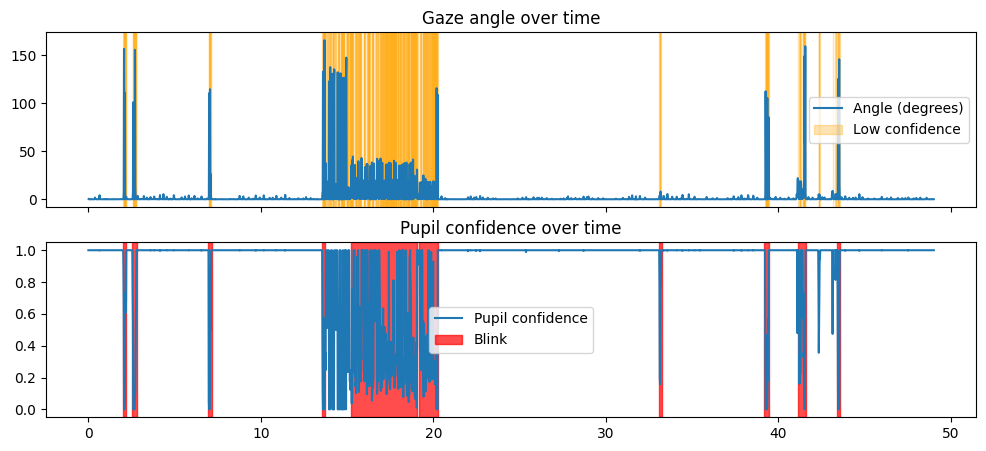

In [137]:
# Create a dataframe with (x,y,z) from current and previous timestamp on the same rows
from matplotlib import pyplot as plt


gaze_angular_data = merged_df_clean_resampled[['timestamp', 'gaze_point_3d_x', 'gaze_point_3d_y', 'gaze_point_3d_z']].copy()
gaze_angular_data['prev_gaze_point_3d_x'] = gaze_angular_data['gaze_point_3d_x'].shift(1)
gaze_angular_data['prev_gaze_point_3d_y'] = gaze_angular_data['gaze_point_3d_y'].shift(1)
gaze_angular_data['prev_gaze_point_3d_z'] = gaze_angular_data['gaze_point_3d_z'].shift(1)
gaze_angular_data.drop(index=0, inplace=True)  # Drop the first row which has NaN values
gaze_angular_data.head()

gaze_angular_data['gaze_angle'] = gaze_angular_data.apply(calculate_angle, axis=1)
fig, axs = plt.subplots(2,1,figsize=(12, 5), sharex=True)
axs[0].plot(gaze_angular_data['timestamp'], gaze_angular_data['gaze_angle'])
axs[0].title.set_text("Gaze angle over time")

gaze_angular_data['low_confidence'] = merged_df_clean_resampled['pupil_confidence'] < 0.95

# Let's check when are the blinks occurring in the gaze angle data
blink_df_clean = blink_df.copy()
blink_df_clean['timestamp'] = blink_df_clean['start_timestamp'] - gaze_start_time
# Let's mark zones with low confidence
for _, row in gaze_angular_data[gaze_angular_data.low_confidence].iterrows():
    axs[0].axvspan(row['timestamp'], row['timestamp'] + 1.0/240, color='orange', alpha=0.3)

# Let's also add the confidence level over time on the same plot
y_data = merged_df_clean_resampled[['timestamp', 'pupil_confidence']].set_index('timestamp')
axs[1].plot(y_data.index, y_data['pupil_confidence'])
axs[1].title.set_text("Pupil confidence over time")
for _, row in blink_df_clean.iterrows():
    axs[1].axvspan(row['timestamp'], row['timestamp'] + row['duration'], color='red', alpha=0.7)

axs[0].legend(["Angle (degrees)", "Low confidence"])
axs[1].legend(["Pupil confidence", "Blink"])


Let's measure the different gaps of low confidence (to eventually label blinks)

In [138]:
low_confidence_df = merged_df_clean_resampled[['timestamp', 'pupil_confidence', 'ellipse_axis_a']].copy()
low_confidence_df['low_confidence'] = low_confidence_df['pupil_confidence'] < 0.95
low_confidence_df['transition'] = low_confidence_df['low_confidence'] != low_confidence_df['low_confidence'].shift(1)
low_confidence_df['group'] = low_confidence_df['transition'].cumsum()
low_confidence_df['id'] = low_confidence_df.index
low_confidence_df_gfoup = low_confidence_df.groupby('group').agg({'low_confidence': ['first', 'count'], 'timestamp': ['min', 'max'], 'ellipse_axis_a': ['min', 'max'], 'id': ['min', 'max']})
low_confidence_df_gfoup['duration_ms'] = (low_confidence_df_gfoup['timestamp']['max'] - low_confidence_df_gfoup['timestamp']['min']) * 1000
low_confidence_df_gfoup['openness_delta'] = low_confidence_df_gfoup['ellipse_axis_a']['max'] - low_confidence_df_gfoup['ellipse_axis_a']['min']
low_confidence_df_gfoup[low_confidence_df_gfoup['low_confidence']['first']].head()

print(f"Number of low confidence periods with a single sample: {(low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['low_confidence']['count'] == 1)).sum()}")
print(f"Number of low confidence periods with a duration less than 100 ms: {(low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['duration_ms'] < 100)).sum()}")
print(f"Number of possible blink candidates [100-300 ms]: {(low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['duration_ms'] >= 100) & (low_confidence_df_gfoup['duration_ms'] <= 300)).sum()}")
print(f"Number of long low confidence periods (> 300 ms): {(low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['duration_ms'] > 300)).sum()}")

gaps_to_fill_df = low_confidence_df_gfoup[low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['duration_ms'] < 100)]
gaps_to_fill_df = gaps_to_fill_df[[('id', 'min'), ('id', 'max'), ('timestamp', 'min'), ('timestamp', 'max')]].reset_index(drop=True)
gaps_to_fill_df[('id','min')] = gaps_to_fill_df[('id','min')].astype(int)
gaps_to_fill_df[('id','max')] = gaps_to_fill_df[('id','max')].astype(int)

display(gaps_to_fill_df.head())

average_openness_delta_valid_samples = low_confidence_df_gfoup[(~low_confidence_df_gfoup['low_confidence']['first'])]['openness_delta'].mean()
print(f"Average openness delta for valid samples: {average_openness_delta_valid_samples:.2f} mm")
low_confidence_df_gfoup[(low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['duration_ms'] >= 100) & (low_confidence_df_gfoup['duration_ms'] <= 300))]

custom_blinks_df = low_confidence_df_gfoup[(low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['duration_ms'] >= 100) & (low_confidence_df_gfoup['duration_ms'] <= 300))].copy()
custom_blinks_df['start_timestamp'] = custom_blinks_df['timestamp']['min']
custom_blinks_df['stop_timestamp'] = custom_blinks_df['timestamp']['max']
custom_blinks_df['start_id'] = custom_blinks_df['id']['min']
custom_blinks_df['stop_id'] = custom_blinks_df['id']['max']
custom_blinks_df = custom_blinks_df[['start_id', 'stop_id', 'start_timestamp', 'stop_timestamp', 'duration_ms']].reset_index(drop=True)
custom_blinks_df = custom_blinks_df.droplevel(level=1, axis=1)
custom_blinks_df.head()

Number of low confidence periods with a single sample: 9
Number of low confidence periods with a duration less than 100 ms: 25
Number of possible blink candidates [100-300 ms]: 19
Number of long low confidence periods (> 300 ms): 5


id      timestamp          
   min  max       min       max
0  830  833  13.83610  13.88611
1  858  861  14.30286  14.35287
2  886  890  14.76962  14.83630
3  896  896  14.93632  14.93632
4  898  903  14.96966  15.05301

Average openness delta for valid samples: 2.93 mm


,start_id,stop_id,start_timestamp,stop_timestamp,duration_ms
0,122,131,2.03374,2.18377,150.03
1,154,167,2.56718,2.78389,216.71
2,419,426,6.98473,7.10142,116.69
3,814,825,13.56938,13.75275,183.37
4,837,843,13.95279,14.05281,100.02


Let's try to interpolate missing values starting with the blinks intervals

Also let's truncate the end because the particiapnt was probably moving away from the screen, making the data erronous (not meaningful anyway)

In [139]:
def calculate_gaze_angular_delta(df):
    gaze_angular_data = df[['timestamp', 'gaze_point_3d_x', 'gaze_point_3d_y', 'gaze_point_3d_z']].copy()
    gaze_angular_data['prev_gaze_point_3d_x'] = gaze_angular_data['gaze_point_3d_x'].shift(1)
    gaze_angular_data['prev_gaze_point_3d_y'] = gaze_angular_data['gaze_point_3d_y'].shift(1)
    gaze_angular_data['prev_gaze_point_3d_z'] = gaze_angular_data['gaze_point_3d_z'].shift(1)

    gaze_angular_data['gaze_angle_delta_deg'] = gaze_angular_data.apply(calculate_angle, axis=1)
    return gaze_angular_data['gaze_angle_delta_deg']

In [140]:
eye_data_df = merged_df_clean_resampled.copy()
eye_data_df['gaze_angle_delta_deg'] = calculate_gaze_angular_delta(eye_data_df)
# First, for the gaze data, just drop the samples in the blinks since interpolating is meaningless
MARGIN = 5
interpolated_gaze_df = eye_data_df[
    ['timestamp', 'gaze_angle_delta_deg', 
     'gaze_point_3d_x', 'gaze_point_3d_y', 'gaze_point_3d_z', 
     'norm_pos_x', 'norm_pos_y']
].copy()
for _, row in custom_blinks_df.iterrows():
    # Set gaze points to NaN
    columns = [c for c in interpolated_gaze_df.columns if c not in ['timestamp', 'interpolated']]
    interpolated_gaze_df.loc[(interpolated_gaze_df.index >= row['start_id'] - MARGIN) & (interpolated_gaze_df.index <= row['stop_id'] + MARGIN), columns] = np.nan
interpolated_gaze_df['gaze_angle_delta_deg'].isna().sum()

np.int64(334)

In [141]:
from scipy.interpolate import interp1d

def interpolate_blinks(pupil_df, blink_df, N=100, MIN_SAMPLES=5, MARGIN=5):
    if 'pupil_diameter_mm' not in pupil_df.columns:
        raise ValueError("pupil_df must contain 'pupil_diameter_mm' column")
    
    if not {'start_id', 'stop_id'}.issubset(blink_df.columns):
        raise ValueError("blink_df must contain 'start_id' and 'stop_id' columns")
    
    pupil_df = pupil_df.copy()
    if 'interpolated' not in pupil_df.columns:
        pupil_df['interpolated'] = False
    inter_data_df = pd.DataFrame(
        columns=['blink_id', 
                 'original_pupil_diameter_mm', 
                 'inter_pupil_diameter_mm']
    )
    for idx, blink in blink_df.iterrows():
        start_id = blink['start_id'].astype(int)
        stop_id = blink['stop_id'].astype(int)
        
        if start_id < 0 or stop_id > pupil_df.index.max():
            print(f"Skipping invalid blink with start_id {start_id} and stop_id {stop_id}")
            continue

        # Check if window around the data fits within the dataframe
        window_start = max(0, start_id - N // 2)
        window_end = min(len(pupil_df) - 1, stop_id + N // 2)
        pre_samples_count = (start_id - MARGIN) -window_start
        post_samples_count = window_end - (stop_id + MARGIN)
        if pre_samples_count < MIN_SAMPLES or post_samples_count < MIN_SAMPLES:
            print(f"Skipping blink with insufficient data around start_id {start_id} and stop_id {stop_id}")
            continue

        # For interpolation, using timestamps outside the blinks
        pre_blink_data = pupil_df.loc[window_start:start_id - MARGIN - 1, 'pupil_diameter_mm']
        post_blink_data = pupil_df.loc[stop_id + MARGIN + 1:window_end, 'pupil_diameter_mm']
        x = pd.concat([pre_blink_data, post_blink_data]).index
        y = pd.concat([pre_blink_data, post_blink_data]).values
        interp_func = interp1d(x, y, kind='slinear')
        blink_indices = range(start_id - MARGIN, stop_id + MARGIN + 1)
        interpolated_values = interp_func(blink_indices)
        original_values = pupil_df.loc[blink_indices, 'pupil_diameter_mm'].copy().values
        pupil_df.loc[blink_indices, 'pupil_diameter_mm'] = interpolated_values
        pupil_df.loc[blink_indices, 'interpolated'] = True
        inter_data_df = pd.concat([
            inter_data_df,
            pd.DataFrame({
                'blink_id': idx,
                'original_pupil_diameter_mm': original_values,
                'inter_pupil_diameter_mm': interpolated_values
            })
        ], ignore_index=True)

    return pupil_df, inter_data_df

pupil_df = eye_data_df[['timestamp', 'pupil_diameter_mm', 'pupil_confidence']].copy()
inter_pupil_df, inter_pupil_analysis_df = interpolate_blinks(pupil_df, custom_blinks_df)
display(custom_blinks_df.stop_id)


0      131
1      167
2      426
3      825
4      843
5      854
6      873
7      884
8      921
9      934
10     949
11     979
12    1089
13    1101
14    1116
15    1191
16    2365
17    2493
18    2612
Name: stop_id, dtype: int64

Final samples number for interpolated gaze & pupil: 2931


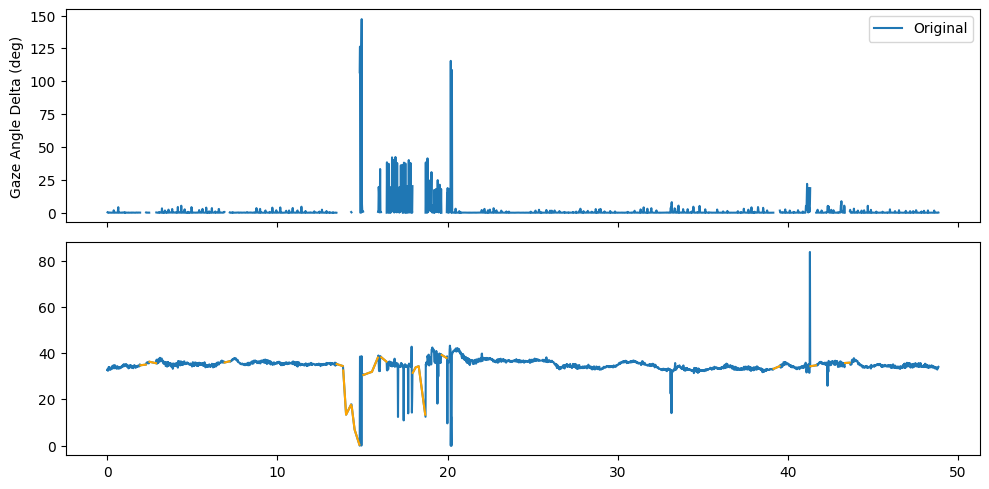

In [142]:
# Lets remove the last samples because meaningless here
inter_merged_eye_df = pd.merge(inter_pupil_df[['timestamp', 'pupil_diameter_mm', 'interpolated', 'pupil_confidence']], interpolated_gaze_df, on='timestamp', how='inner', suffixes=('_pupil', '_gaze'))
inter_merged_eye_df = inter_merged_eye_df[:-10]
print(f"Final samples number for interpolated gaze & pupil: {len(inter_merged_eye_df)}")

fig, axs = plt.subplots(2,1,figsize=(10, 5), sharex=True)
axs[0].plot(inter_merged_eye_df['timestamp'], inter_merged_eye_df['gaze_angle_delta_deg'])
# inter_merged_eye_df['transistion_gaze'] = inter_merged_eye_df['interpolated_gaze'] != inter_merged_eye_df['interpolated_gaze'].shift(1)
# grouped_eye_data = inter_merged_eye_df.groupby(inter_merged_eye_df['transistion_gaze'].cumsum())
# for name, group in grouped_eye_data:
#     if group.iloc[0]['interpolated_gaze']:
#         axs[0].plot(group['timestamp'], group['gaze_angle_delta_deg'], color='orange')
axs[0].set_ylabel('Gaze Angle Delta (deg)')
axs[0].legend(['Original', 'Interpolated'])
axs[1].plot(inter_merged_eye_df['timestamp'], inter_merged_eye_df['pupil_diameter_mm'])
# axs[1].set_ylim(30, 50)
inter_merged_eye_df['transistion_pupil'] = inter_merged_eye_df['interpolated'] != inter_merged_eye_df['interpolated'].shift(1)
grouped_pupil_data = inter_merged_eye_df.groupby(inter_merged_eye_df['transistion_pupil'].cumsum())
for name, group in grouped_pupil_data:
    if group.iloc[0]['interpolated']:
        axs[1].plot(group['timestamp'], group['pupil_diameter_mm'], color='orange')
inter_merged_eye_df.drop(columns=['transistion_pupil'], inplace=True)
plt.tight_layout()
plt.show()

Now, let's fill up the remaining gaps that were not blinks (if not too long, otherwise drop it)

In [143]:
from scipy.interpolate import interp1d
def interpolate_missing_gaze(eye_data_df, gaps_df, N=100, MIN_MARGINS=10):
    if 'gaze_angle_delta_deg' not in eye_data_df.columns:
        raise ValueError("eye_data_df must contain 'gaze_angle_delta_deg' column")
    if 'pupil_diameter_mm' not in eye_data_df.columns:
        raise ValueError("eye_data_df must contain 'pupil_diameter_mm' column")
    
    if 'id' not in gaps_df.columns:
        raise ValueError("gaps_df must contain 'id' column with 'min' and 'max' keys")
    
    eye_data_df = eye_data_df.copy()
    eye_data_df['interpolated'] = False
    inter_data_df = pd.DataFrame(
        columns=['gap_id', 
                 'original_gaze_angle_delta_deg', 
                 'original_pupil_diameter_mm', 
                 'inter_gaze_angle_delta_deg', 
                 'inter_pupil_diameter_mm'])
    
    for _, gap in gaps_df.iterrows():
        start_id = gap[('id', 'min')].astype(int)
        stop_id = gap[('id', 'max')].astype(int)
        
        if start_id < 0 or stop_id >= len(eye_data_df):
            print(f"Skipping invalid gap with start_id {start_id} and stop_id {stop_id}")
            continue

        # Check if window around the data fits within the dataframe
        window_start = max(0, start_id - N // 2)
        window_end = min(len(eye_data_df) - 1, stop_id + N // 2)
        pre_samples_count = (start_id - MARGIN) -window_start
        post_samples_count = window_end - (stop_id + MARGIN)
        if pre_samples_count < MIN_MARGINS or post_samples_count < MIN_MARGINS:
            print(f"Skipping gap with insufficient data around start_id {start_id} and stop_id {stop_id}")
            continue

        # Discard other low confidence samples (gaps) in the currrent window
        # to avoid using them for interpolation
        gaps_in_window = gaps_df[(gaps_df[('id', 'min')] >= window_start) & (gaps_df[('id', 'max')] <= window_end)]
        if (gaps_in_window[('id', 'max')] - gaps_in_window[('id', 'min')]).sum() > 0.5*N:
            print(f"Skipping gap with too many other gaps in the window around start_id {start_id} and stop_id {stop_id}")
            continue

        # For interpolation, using timestamps outside the gaps
        indices = list(range(window_start, window_end + 1))
        for _, other_gap in gaps_in_window.iterrows():
            other_start_id = other_gap[('id', 'min')].astype(int)
            other_stop_id = other_gap[('id', 'max')].astype(int)
            for i in range(other_start_id, other_stop_id + 1):
                indices.remove(i)
        x = eye_data_df.loc[indices, 'timestamp']
        y_angle = eye_data_df.loc[indices, 'gaze_angle_delta_deg']
        y_pupil = eye_data_df.loc[indices, 'pupil_diameter_mm']
        
        # Create interpolation functions
        interp_angle = interp1d(x, y_angle, kind='linear')
        interp_pupil = interp1d(x, y_pupil, kind='linear')
        
        # Interpolate values for the gap
        gap_timestamps = eye_data_df.loc[start_id:stop_id, 'timestamp']
        interpolated_angles = interp_angle(gap_timestamps)
        interpolated_pupils = interp_pupil(gap_timestamps)
        
        original_angles = eye_data_df.loc[start_id:stop_id, 'gaze_angle_delta_deg'].copy().values
        original_pupils = eye_data_df.loc[start_id:stop_id, 'pupil_diameter_mm'].copy().values
        # Fill in the interpolated values
        eye_data_df.loc[start_id:stop_id, 'gaze_angle_delta_deg'] = interpolated_angles
        eye_data_df.loc[start_id:stop_id, 'pupil_diameter_mm'] = interpolated_pupils
        eye_data_df.loc[start_id:stop_id, 'interpolated'] = True

        # Store interpolation data for analysis
        inter_data_df = pd.concat([inter_data_df, pd.DataFrame({
            'gap_id': start_id,
            'original_gaze_angle_delta_deg': original_angles,
            'original_pupil_diameter_mm': original_pupils,
            'inter_gaze_angle_delta_deg': interpolated_angles,
            'inter_pupil_diameter_mm': interpolated_pupils
        })], ignore_index=True)

    return eye_data_df, inter_data_df

interpolated_eye_data_df, interpolation_analysis_df = interpolate_missing_gaze(inter_merged_eye_df, gaps_to_fill_df)
print(f"Interpolated {len(interpolation_analysis_df['gap_id'].unique())} samples across {gaps_to_fill_df.shape[0]} gaps")
interpolation_analysis_df.head()

Interpolated 25 samples across 25 gaps


,gap_id,original_gaze_angle_delta_deg,original_pupil_diameter_mm,inter_gaze_angle_delta_deg,inter_pupil_diameter_mm
0,830,NaN,34.47066,NaN,33.346082
1,830,0.985063,34.432066,NaN,32.182908
2,830,NaN,32.519173,NaN,31.019735
3,830,NaN,30.606281,NaN,29.856562
4,858,NaN,17.350219,NaN,17.053298


Index(['timestamp', 'pupil_diameter_mm', 'interpolated', 'pupil_confidence',
       'gaze_angle_delta_deg', 'gaze_point_3d_x', 'gaze_point_3d_y',
       'gaze_point_3d_z', 'norm_pos_x', 'norm_pos_y'],
      dtype='str')

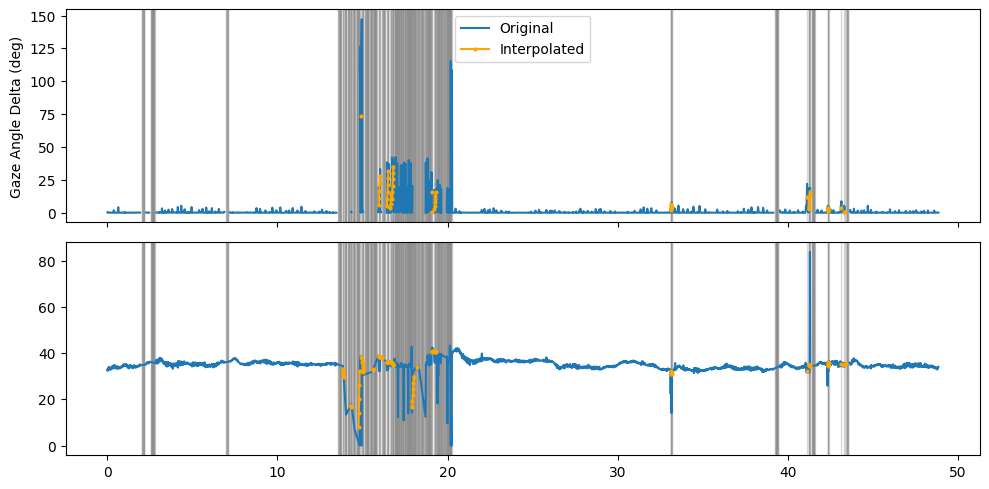

In [144]:
# Lets check out the interpolated data
fig, axs = plt.subplots(2,1,figsize=(10, 5), sharex=True)
axs[0].plot(inter_merged_eye_df['timestamp'], inter_merged_eye_df['gaze_angle_delta_deg'])
interpolated_eye_data_df['transistion'] = interpolated_eye_data_df['interpolated'] != interpolated_eye_data_df['interpolated'].shift(1)
grouped_eye_data = interpolated_eye_data_df.groupby(interpolated_eye_data_df['transistion'].cumsum())
for name, group in grouped_eye_data:
    if group.iloc[0]['interpolated']:
        axs[0].plot(group['timestamp'], group['gaze_angle_delta_deg'], color='orange', marker='o', markersize=2)
# Also add back low confidence zones for reference
display(inter_merged_eye_df.columns)
for _, row in inter_merged_eye_df[inter_merged_eye_df['pupil_confidence'] < 0.95].iterrows():
    axs[0].axvspan(row['timestamp'], row['timestamp'] + 1.0/240, color='gray', alpha=0.3)
axs[0].set_ylabel('Gaze Angle Delta (deg)')
axs[0].legend(['Original', 'Interpolated'])
axs[1].plot(inter_merged_eye_df['timestamp'], inter_merged_eye_df['pupil_diameter_mm'])
for name, group in grouped_eye_data:
    if group.iloc[0]['interpolated']:
        axs[1].plot(group['timestamp'], group['pupil_diameter_mm'], color='orange', marker='o', markersize=2)
for _, row in inter_merged_eye_df[inter_merged_eye_df['pupil_confidence'] < 0.95].iterrows():
    axs[1].axvspan(row['timestamp'], row['timestamp'] + 1.0/240, color='gray', alpha=0.3)
plt.tight_layout()
plt.show()

np.float64(0.01667)

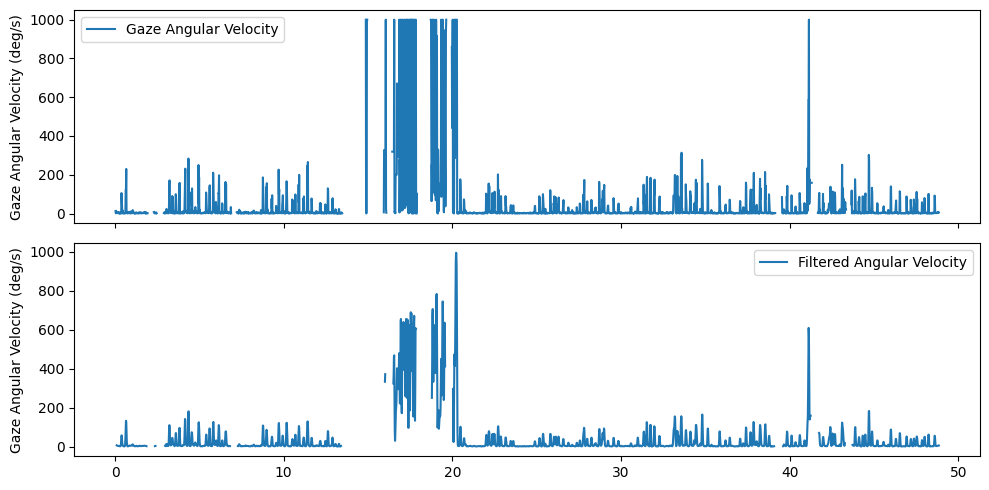

In [145]:
def calculate_angular_velocity(gaze_df, absolute=True, LIMITS=(-1000, 1000)):
    if 'gaze_angle_delta_deg' not in gaze_df.columns:
        raise ValueError("gaze_df must contain 'gaze_angle_delta_deg' column")

    gaze_angular_data = gaze_df[['timestamp', 'gaze_angle_delta_deg']].copy()
    gaze_angular_data['prev_gaze_angle_delta_deg'] = gaze_angular_data['gaze_angle_delta_deg'].shift(1)
    gaze_angular_data['delta_time'] = (gaze_angular_data['timestamp'] - gaze_angular_data['timestamp'].shift(1))
    display(gaze_angular_data['delta_time'].mean())

    def angular_velocity(row):
        if pd.isna(row['prev_gaze_angle_delta_deg']) or pd.isna(row['gaze_angle_delta_deg']):
            return np.nan
        delta_angle = row['gaze_angle_delta_deg'] - row['prev_gaze_angle_delta_deg']
        delta_time = row['delta_time']
        if delta_time == 0:
            return np.nan
        angular_velocity = delta_angle / delta_time
        angular_velocity = np.clip(angular_velocity, LIMITS[0], LIMITS[1])
        return abs(angular_velocity) if absolute else angular_velocity
    
    gaze_angular_data['gaze_angular_velocity'] = gaze_angular_data.apply(angular_velocity, axis=1)
    return gaze_angular_data['gaze_angular_velocity']

interpolated_eye_data_df['gaze_angular_velocity'] = calculate_angular_velocity(interpolated_eye_data_df, absolute=True)
fig, axs = plt.subplots(2,1,figsize=(10, 5), sharex=True)
axs[0].plot(interpolated_eye_data_df['timestamp'], interpolated_eye_data_df['gaze_angular_velocity'])
axs[0].set_ylabel('Gaze Angular Velocity (deg/s)')
axs[0].legend(['Gaze Angular Velocity'])

# Let's filter a bit the angular velocity to remove high frequency noise
# Using a 5-tap FIR filter
# Since our data is gonna be real time at some point
from scipy.signal import firwin, filtfilt

def apply_fir_filter(data, column, cutoff_freq, fs, numtaps=5):
    fir_coefficients = firwin(numtaps, cutoff_freq, fs=fs)
    filtered_data = filtfilt(fir_coefficients, [1.0], data[column])
    return filtered_data

CUTOFF_FREQ = 10  # Hz
FS = 60  # Hz
TAPS = 5
interpolated_eye_data_df['gaze_angular_velocity_filtered'] = apply_fir_filter(interpolated_eye_data_df, 'gaze_angular_velocity', CUTOFF_FREQ, FS, numtaps=TAPS)
axs[1].plot(interpolated_eye_data_df['timestamp'], interpolated_eye_data_df['gaze_angular_velocity_filtered'])
axs[1].set_ylabel('Gaze Angular Velocity (deg/s)')
axs[1].legend(['Filtered Angular Velocity'])
# axs[0].set_ylim(0,20)
# axs[1].set_ylim(0,20)
plt.tight_layout()
plt.show()

Found 183 transitions between saccades and fixations
Will mark 49 short fixations as saccades


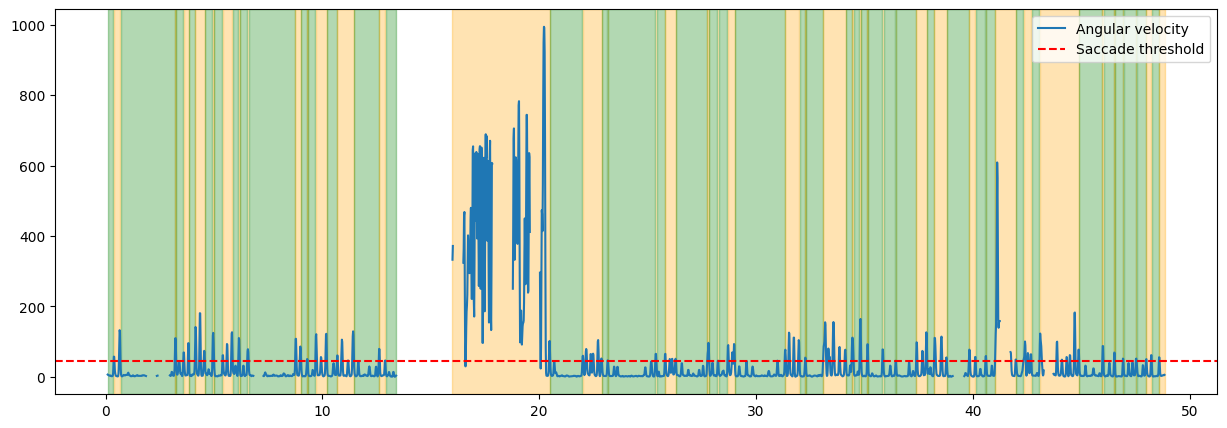

In [146]:
VELOCITY_THRESH = 45

interpolated_gaze_feature_df = interpolated_eye_data_df.copy().dropna()
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(interpolated_eye_data_df['timestamp'], interpolated_eye_data_df['gaze_angular_velocity_filtered'], label='Angular velocity')
ax.axhline(VELOCITY_THRESH, color='red', linestyle='--', label='Saccade threshold')
ax.legend()

# Let's mark the zones for saccades and fixations based on the angular velocity
interpolated_gaze_feature_df['saccade'] = interpolated_gaze_feature_df['gaze_angular_velocity_filtered'] > VELOCITY_THRESH
interpolated_gaze_feature_df['fixation'] = ~interpolated_gaze_feature_df['saccade']
interpolated_gaze_feature_df['transition'] = interpolated_gaze_feature_df['saccade'] != interpolated_gaze_feature_df['saccade'].shift(1)
print(f"Found {interpolated_gaze_feature_df['transition'].sum()} transitions between saccades and fixations")

# 1- Fixations should have a minimum duration of 55 ms (COLET dataset) ~15 datapoins
interpolated_gaze_feature_df['transition'] = interpolated_gaze_feature_df['saccade'] != interpolated_gaze_feature_df['saccade'].shift(1)
interpolated_gaze_feature_df['id'] = interpolated_gaze_feature_df.index
grouped_transitions = interpolated_gaze_feature_df.groupby(interpolated_gaze_feature_df['transition'].cumsum())
# find groups of fixations with a duration less than 55 ms and mark them as saccades
fixation_groups = grouped_transitions.agg({'fixation': ['first', 'count'], 'id': ['min', 'max']})
print(f"Will mark {((fixation_groups[('fixation', 'count')] < 15) & (fixation_groups[('fixation', 'first')])).sum()} short fixations as saccades")
for idx, group in fixation_groups.iterrows():
    if group['fixation']['count'] < 15 and group['fixation']['first']:  # 55 ms at 250 Hz sampling rate
        # Mark the entire group as saccade
        interpolated_gaze_feature_df.loc[group['id']['min']:group['id']['max'], 'saccade'] = True
        interpolated_gaze_feature_df.loc[group['id']['min']:group['id']['max'], 'fixation'] = False


# Merge if only one sample in the transition to avoid marking very short saccades or fixations
interpolated_gaze_feature_df['saccade'] = interpolated_gaze_feature_df['saccade'].astype(np.int32)
interpolated_gaze_feature_df['fixation'] = interpolated_gaze_feature_df['fixation'].astype(np.int32)
interpolated_gaze_feature_df['transition'] = interpolated_gaze_feature_df['saccade'] != interpolated_gaze_feature_df['saccade'].shift(1)
grouped_transitions = interpolated_gaze_feature_df.groupby(interpolated_gaze_feature_df['transition'].cumsum())
single_samples = grouped_transitions.agg({'saccade': 'count', 'id': 'first', 'fixation': 'count'})
single_samples = single_samples[(single_samples['saccade'] == 1) | (single_samples['fixation'] == 1)]['id']
interpolated_gaze_feature_df.loc[single_samples, 'saccade'] = pd.NA
interpolated_gaze_feature_df.loc[single_samples, 'fixation'] = pd.NA
# Interpolate nearest neighbor to fill the single sample gaps
interpolated_gaze_feature_df['saccade'] = interpolated_gaze_feature_df['saccade'].interpolate(method='nearest')
interpolated_gaze_feature_df['fixation'] = interpolated_gaze_feature_df['fixation'].interpolate(method='nearest')
interpolated_gaze_feature_df['saccade'] = interpolated_gaze_feature_df['saccade'].astype(np.bool)
interpolated_gaze_feature_df['fixation'] = interpolated_gaze_feature_df['fixation'].astype(np.bool)

interpolated_gaze_feature_df['transition'] = interpolated_gaze_feature_df['saccade'] != interpolated_gaze_feature_df['saccade'].shift(1)
grouped_transitions = interpolated_gaze_feature_df.groupby(interpolated_gaze_feature_df['transition'].cumsum())
for idx, group in grouped_transitions:
    if group.iloc[0]['saccade']:
        ax.axvspan(group.iloc[0]['timestamp'], group.iloc[-1]['timestamp'], color='orange', alpha=0.3)
    else:
        ax.axvspan(group.iloc[0]['timestamp'], group.iloc[-1]['timestamp'], color='green', alpha=0.3)

Text(0.5, 1.0, 'Fixation Centroids and Radius')

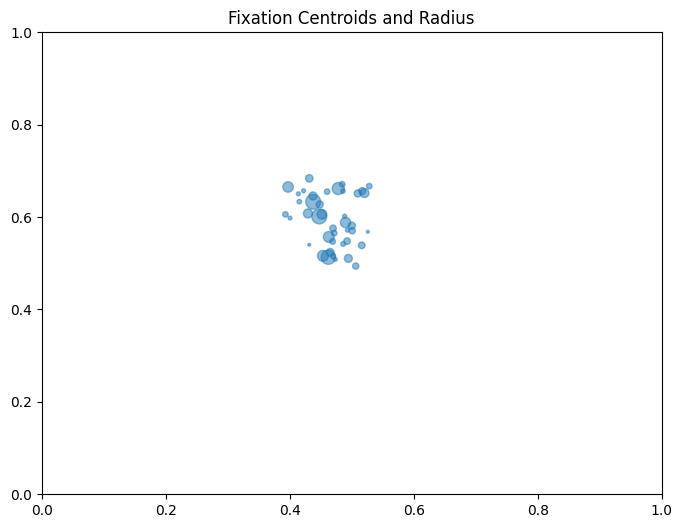

In [147]:
# Lets create a df for the fixations infos
fixation_durations = []
fixation_positions = []
fixation_radius = []
fixation_timestamps = []

grouped_transitions = interpolated_gaze_feature_df.groupby(interpolated_gaze_feature_df['transition'].cumsum())
for idx, group in grouped_transitions:
    if not group.iloc[0]['saccade']:
        fixation_durations.append(group.shape[0] / 250)  # Convert to seconds (assuming 250 Hz sampling rate)
        mean_x, mean_y = group['norm_pos_x'].mean(), group['norm_pos_y'].mean()
        fixation_positions.append((mean_x, mean_y))
        fixation_radius.append(((group['norm_pos_x']-mean_x)**2 + (group['norm_pos_y']-mean_y)**2).max()**0.5)  # Approximate radius as distance from mean position
        fixation_timestamps.append(group.iloc[0]['timestamp'])

fixation_df = pd.DataFrame({
    'duration': fixation_durations,
    'x': [pos[0] for pos in fixation_positions],
    'y': [pos[1] for pos in fixation_positions],
    'radius': fixation_radius,
    'timestamp': fixation_timestamps
})
len(fixation_df)

# Plot the fixation centroid positions and radius using scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(fixation_df['x'], fixation_df['y'], s=fixation_df['radius']*2000, alpha=0.5)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title('Fixation Centroids and Radius')

In [ ]:
# Create the saccade df
saccade_durations = []
saccade_timestamps = []

grouped_transitions = interpolated_gaze_feature_df.groupby(interpolated_gaze_feature_df['transition'].cumsum())
for idx, group in grouped_transitions:
    if group.iloc[0]['saccade']:
        saccade_durations.append(group.shape[0] / 60)  # Convert to seconds (assuming 250 Hz sampling rate)
        saccade_timestamps.append(group.iloc[0]['timestamp'])

saccade_df = pd.DataFrame({
    'duration': saccade_durations,
    'timestamp': saccade_timestamps
})

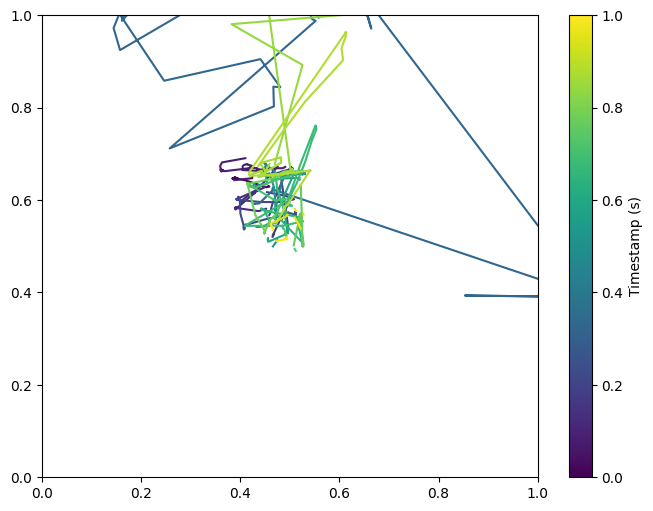

In [149]:
# Plots saccades trails on the normalized screen coordinates
fig, ax = plt.subplots(figsize=(8, 6))
colormap = colormaps.get_cmap("viridis")
for idx, group in interpolated_gaze_feature_df.groupby(interpolated_gaze_feature_df['transition'].cumsum()):
    if group.iloc[0]['saccade']:
        c = colormap(group.iloc[0]['timestamp'] / interpolated_gaze_feature_df['timestamp'].max())  # Normalize saccade value (assuming max saccade value is 100)
        ax.plot(group['norm_pos_x'], group['norm_pos_y'], color=c)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
fig.colorbar(plt.cm.ScalarMappable(cmap=colormap), label='Timestamp (s)', ax=ax)

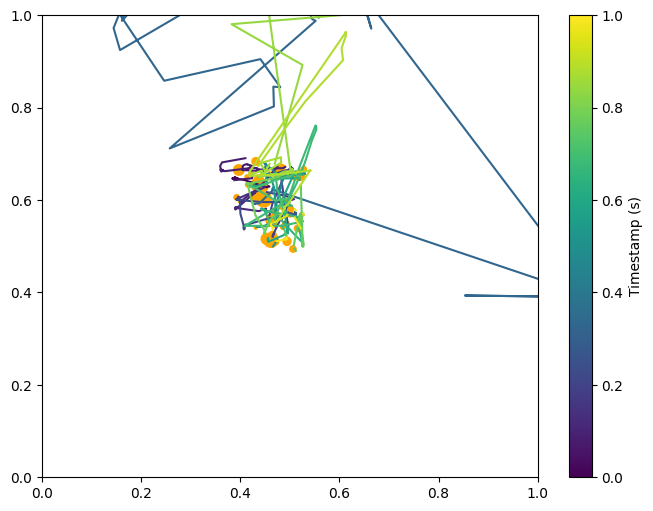

In [150]:
# Combined plot of fixations and saccades
fig, ax = plt.subplots(figsize=(8, 6))
colormap = colormaps.get_cmap("viridis")
ax.scatter(fixation_df['x'], fixation_df['y'], s=fixation_df['radius']*2000, color='orange', label='Fixations')
for idx, group in interpolated_gaze_feature_df.groupby(interpolated_gaze_feature_df['transition'].cumsum()):
    if group.iloc[0]['saccade']:
        c = colormap(group.iloc[0]['timestamp'] / interpolated_gaze_feature_df['timestamp'].max())  # Normalize saccade value (assuming max saccade value is 100)
        ax.plot(group['norm_pos_x'], group['norm_pos_y'], color=c)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
fig.colorbar(plt.cm.ScalarMappable(cmap=colormap), label='Timestamp (s)', ax=ax)

Now its time to look at the pupil diameter change frequency.

1- IPA

Estimated IPA: 0.1638 spikes/s
Duration of the signal: 48.84 seconds


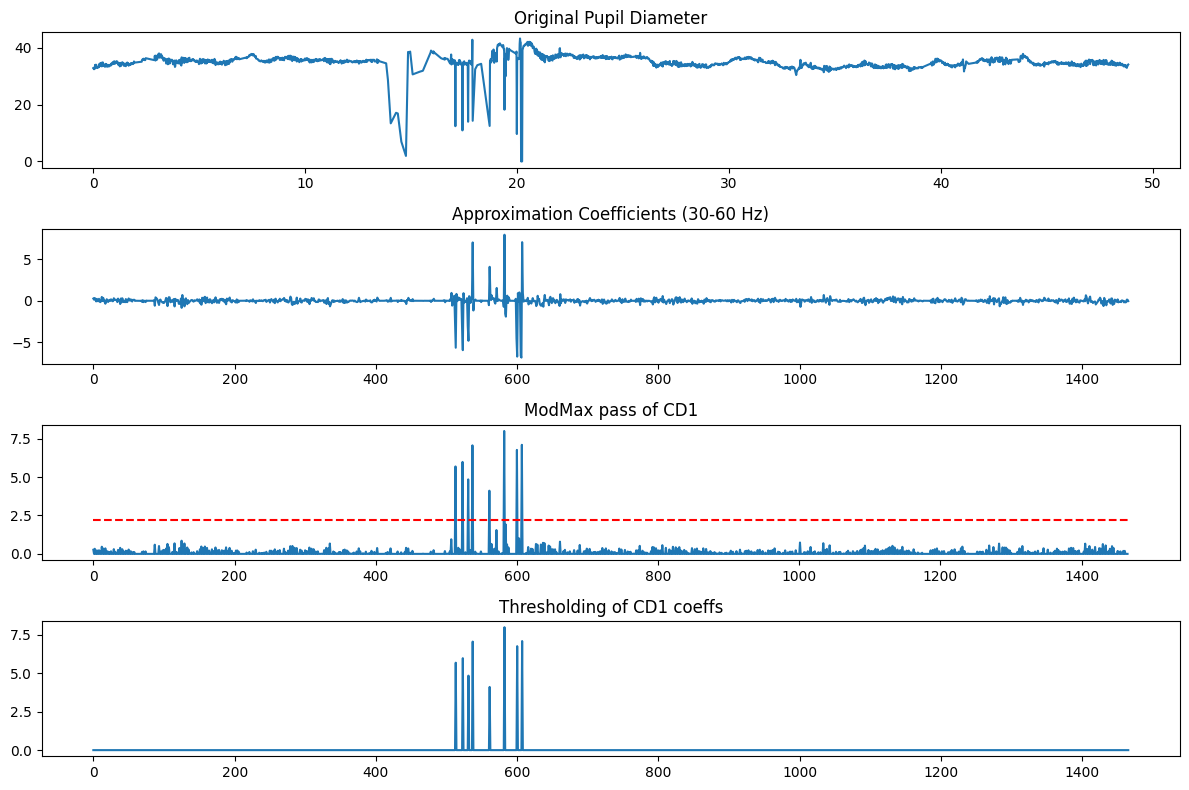

In [151]:
# Lets implement the IPA algorithm
# From the IPA paper (2018 ICRA)
import pywt

LEVELS = 2
TYPE = 'sym4' # @ 60 Hz --> 8*16ms ~ 134ms window 
wv = pywt.Wavelet(TYPE)
x = np.array(interpolated_eye_data_df['pupil_diameter_mm'].values)
cA2, cD2, cD1 = pywt.wavedec(x, wv, level=LEVELS, mode='per')

duration = interpolated_eye_data_df['timestamp'].max() - interpolated_eye_data_df['timestamp'].min()

# Normalize the coefficients by 1/2^j
cA2 /= 2**2
cD2 /= 2**2
cD1 /= 2**1

def modmax(coeffs):
    abs_coeffs = np.abs(np.array(coeffs))
    lcoeffs = np.roll(abs_coeffs, -1)
    lcoeffs[-1] = 0.0
    rcoeffs = np.roll(abs_coeffs, 1)
    rcoeffs[0] = 0.0
    return np.multiply(abs_coeffs, ((abs_coeffs >= lcoeffs) & (abs_coeffs >= rcoeffs)) & ((abs_coeffs > lcoeffs) | (abs_coeffs > rcoeffs)))

cD1m = modmax(cD1)
# Universal threshold for noise estimation
lambda_univ = np.std(cD1m) * np.sqrt(2.0 * np.log2(len(cD1m)))
cD1t = pywt.threshold(cD1m, lambda_univ, mode='hard')

# IPA
spikes = (np.abs(cD1t) > 0).sum()
ipa = spikes / duration

print("Estimated IPA: {:.4f} spikes/s".format(ipa))

print(f"Duration of the signal: {duration:.2f} seconds")
plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(interpolated_eye_data_df['timestamp'][:len(x)], x)
plt.title('Original Pupil Diameter')
plt.subplot(4, 1, 2)
plt.plot(cD1)
plt.title('Approximation Coefficients (30-60 Hz)')
plt.subplot(4, 1, 3)
plt.plot(cD1m)
plt.hlines(lambda_univ, 0, len(cD1m), colors='red', linestyles='--', label='Threshold')
plt.title('ModMax pass of CD1')
plt.subplot(4, 1, 4)
plt.plot(cD1t)
plt.title('Thresholding of CD1 coeffs')
plt.tight_layout()
plt.show()

2- LHIPA

This is an improved version of the classical IPA as it combines low/high threshold ratio, which takes into account the pupil baseline and thus limits the biases

In [152]:
def calculate_lhipa(data):
    w = pywt.Wavelet(TYPE)
    max_level = pywt.dwt_max_level(len(data), w.dec_len)

    hif, lof = 1, int(max_level/2)

    cD_H = pywt.downcoef('d', data, w, level=hif, mode='per')
    cD_L = pywt.downcoef('d', data, w, level=lof, mode='per')

    # Normalize
    cD_H /= np.sqrt(2**hif)
    cD_L /= np.sqrt(2**lof)

    cD_LH = cD_L / cD_H[[i for i in range(len(cD_H)) if i % (2**(lof-hif)) == 0]]

    # Modmax
    cD_LHm = modmax(cD_LH)

    # Universal threshold for noise estimation
    lambda_univ = np.std(cD_LHm) * np.sqrt(2.0 * np.log2(len(cD_LHm)))
    cD_LHt = pywt.threshold(cD_LHm, lambda_univ, mode='less')

    duration = interpolated_eye_data_df['timestamp'].max() - interpolated_eye_data_df['timestamp'].min()

    return (cD_LHt > 0).sum() / duration

Estimated LHIPA: 2.3135 spikes/s


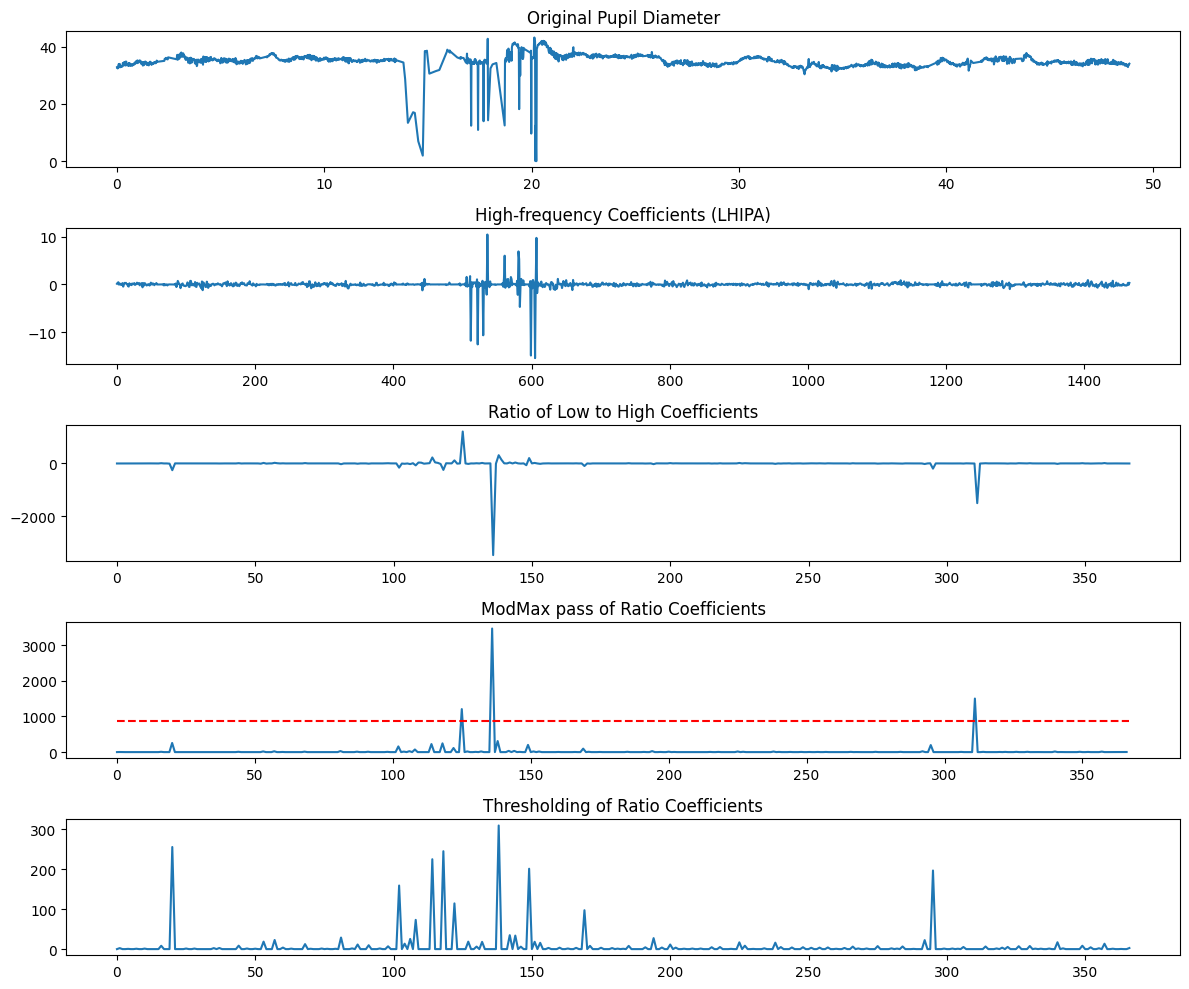

In [153]:
TYPE = 'sym16'

w = pywt.Wavelet(TYPE)
max_level = pywt.dwt_max_level(len(x), w.dec_len)

hif, lof = 1, int(max_level/2)

cD_H = pywt.downcoef('d', x, w, level=hif, mode='per')
cD_L = pywt.downcoef('d', x, w, level=lof, mode='per')

# Normalize
cD_H /= np.sqrt(2**hif)
cD_L /= np.sqrt(2**lof)

cD_LH = cD_L / cD_H[[i for i in range(len(cD_H)) if i % (2**(lof-hif)) == 0]]

# Modmax
cD_LHm = modmax(cD_LH)

# Universal threshold for noise estimation
lambda_univ = np.std(cD_LHm) * np.sqrt(2.0 * np.log2(len(cD_LHm)))
cD_LHt = pywt.threshold(cD_LHm, lambda_univ, mode='less')

duration = interpolated_eye_data_df['timestamp'].max() - interpolated_eye_data_df['timestamp'].min()

lhipa =  (cD_LHt > 0).sum() / duration



print("Estimated LHIPA: {:.4f} spikes/s".format(lhipa))

# Plot everything
plt.figure(figsize=(12, 10))
plt.subplot(5, 1, 1)
plt.plot(interpolated_eye_data_df['timestamp'][:len(x)], x)
plt.title('Original Pupil Diameter')
plt.subplot(5, 1, 2)
plt.plot(cD_H)
plt.title('High-frequency Coefficients (LHIPA)')
plt.subplot(5, 1, 3)
plt.plot(cD_LH)
plt.title('Ratio of Low to High Coefficients')
plt.subplot(5, 1, 4)
plt.plot(cD_LHm)
plt.hlines(lambda_univ, 0, len(cD_LHm), colors='red', linestyles='--', label='Threshold')
plt.title('ModMax pass of Ratio Coefficients')
plt.subplot(5, 1, 5)
plt.plot(cD_LHt)
plt.title('Thresholding of Ratio Coefficients')
plt.tight_layout()
plt.show()

Extracted LHIPA values for 37 windows


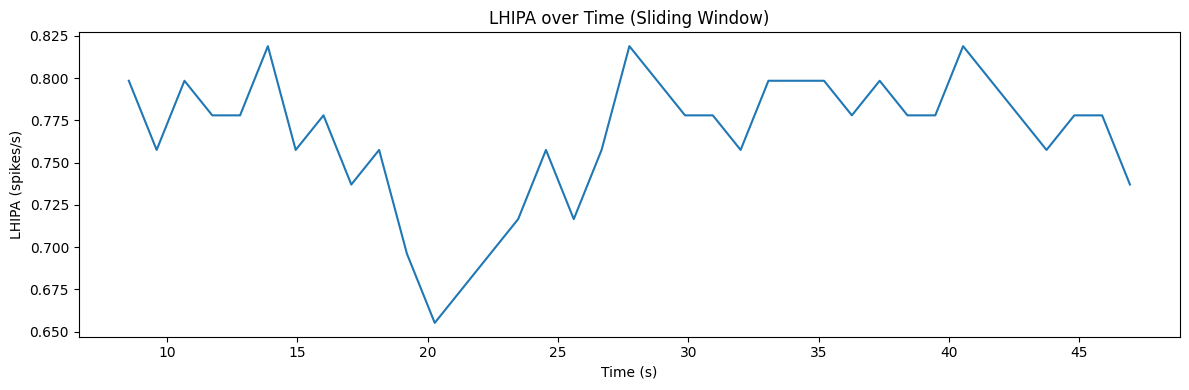

In [154]:
# Low let's try to calculate lhipa over a sliding window with steps of 64 (~ 1s)
WINDOW_SIZE = 512
STEP_SIZE = 64
lhipa_values = []

for latest in range(WINDOW_SIZE, len(x) - STEP_SIZE + 1, STEP_SIZE):
    window_data = x[latest - WINDOW_SIZE:latest]
    lhipa_value = calculate_lhipa(window_data)
    lhipa_values.append((interpolated_eye_data_df['timestamp'].iloc[latest], lhipa_value))

print("Extracted LHIPA values for {} windows".format(len(lhipa_values)))
lhipa_df = pd.DataFrame(lhipa_values, columns=['timestamp', 'lhipa'])
plt.figure(figsize=(12, 4))
plt.plot(lhipa_df['timestamp'], lhipa_df['lhipa'])
plt.title('LHIPA over Time (Sliding Window)')
plt.xlabel('Time (s)')
plt.ylabel('LHIPA (spikes/s)')
plt.tight_layout()

3- WF features in a defnied window of length *w*

In [125]:
# Using the same window size of 512 and step of 64
d = x[:WINDOW_SIZE]
TYPE = 'db8'

max_level = 2 # (0-15 Hz), (15-30 Hz) & (30-60 Hz) frequency bands

# Get all coeffs for the different levels
coeffs = pywt.wavedec(d, TYPE, level=max_level, mode='symmetric')

# Print out the length of each coefficient array
for i, coeff in enumerate(coeffs):
    print(f"Level {i} coefficients length: {len(coeff)}")

Level 0 coefficients length: 139
Level 1 coefficients length: 139
Level 2 coefficients length: 263
